Количество изображений всего: 1912
Cracking: 472
Layer shifting: 364
Off platform: 91
Stringing: 447
Warping: 538

Размеры выборок:
Train: 1338
Validation: 287
Test: 287
Эпоха 1/10 | Train loss: 1.6130 | Train accuracy: 0.2250 | Val loss: 1.5301 | Val accuracy: 0.3206
Эпоха 2/10 | Train loss: 1.4879 | Train accuracy: 0.3244 | Val loss: 1.4263 | Val accuracy: 0.4460
Эпоха 3/10 | Train loss: 1.4018 | Train accuracy: 0.4170 | Val loss: 1.3344 | Val accuracy: 0.5226
Эпоха 4/10 | Train loss: 1.3089 | Train accuracy: 0.5075 | Val loss: 1.2483 | Val accuracy: 0.5993
Эпоха 5/10 | Train loss: 1.2314 | Train accuracy: 0.5620 | Val loss: 1.1729 | Val accuracy: 0.6411
Эпоха 6/10 | Train loss: 1.1642 | Train accuracy: 0.6024 | Val loss: 1.1101 | Val accuracy: 0.6516
Эпоха 7/10 | Train loss: 1.0906 | Train accuracy: 0.6592 | Val loss: 1.0646 | Val accuracy: 0.6725
Эпоха 8/10 | Train loss: 1.0419 | Train accuracy: 0.6846 | Val loss: 1.0105 | Val accuracy: 0.6899
Эпоха 9/10 | Train loss: 0.9921 | Trai

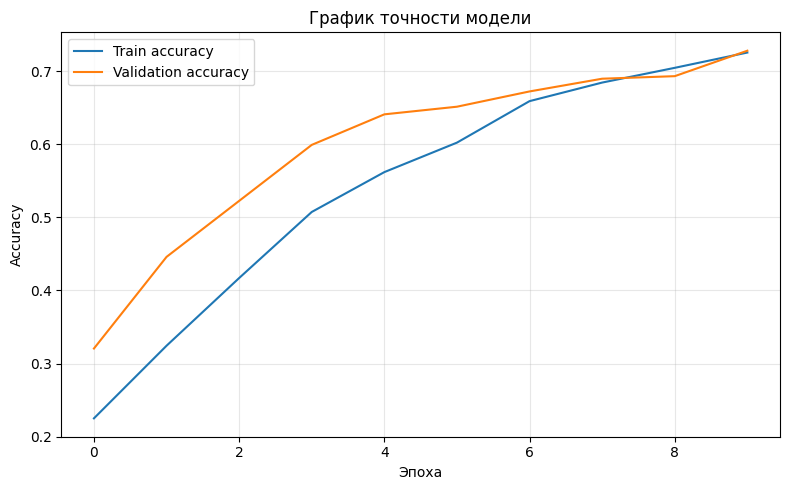

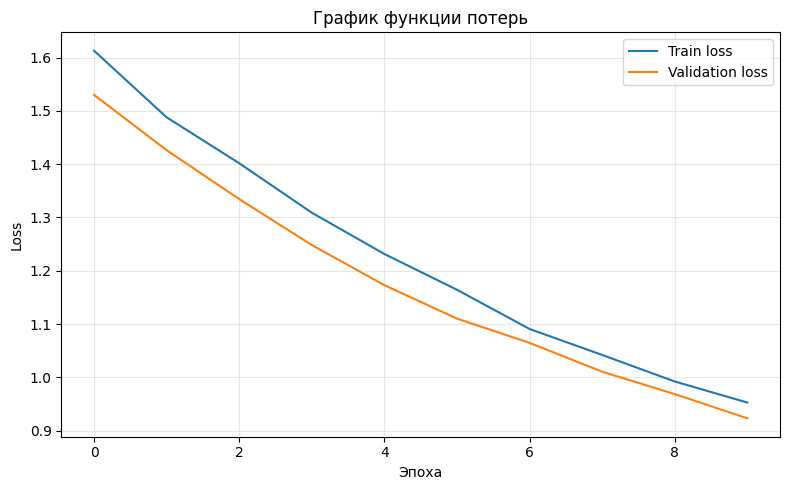


Итоговая оценка на тестовой выборке:
Test loss: 0.9524
Test accuracy: 0.7003

Classification report:
                precision    recall  f1-score   support

      Cracking       0.59      0.55      0.57        71
Layer shifting       0.66      0.67      0.67        55
  Off platform       1.00      0.08      0.14        13
     Stringing       0.98      0.76      0.86        67
       Warping       0.65      0.90      0.76        81

      accuracy                           0.70       287
     macro avg       0.78      0.59      0.60       287
  weighted avg       0.73      0.70      0.69       287



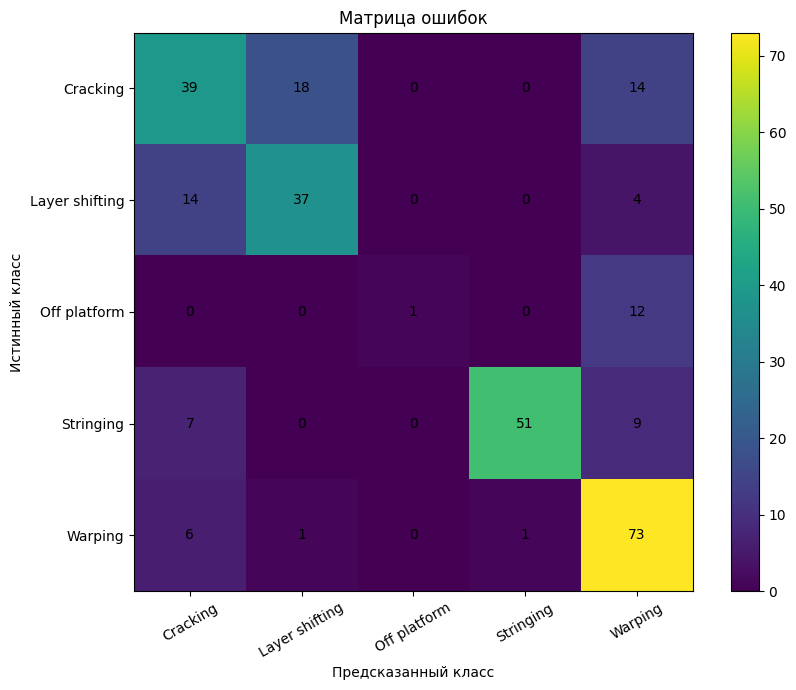

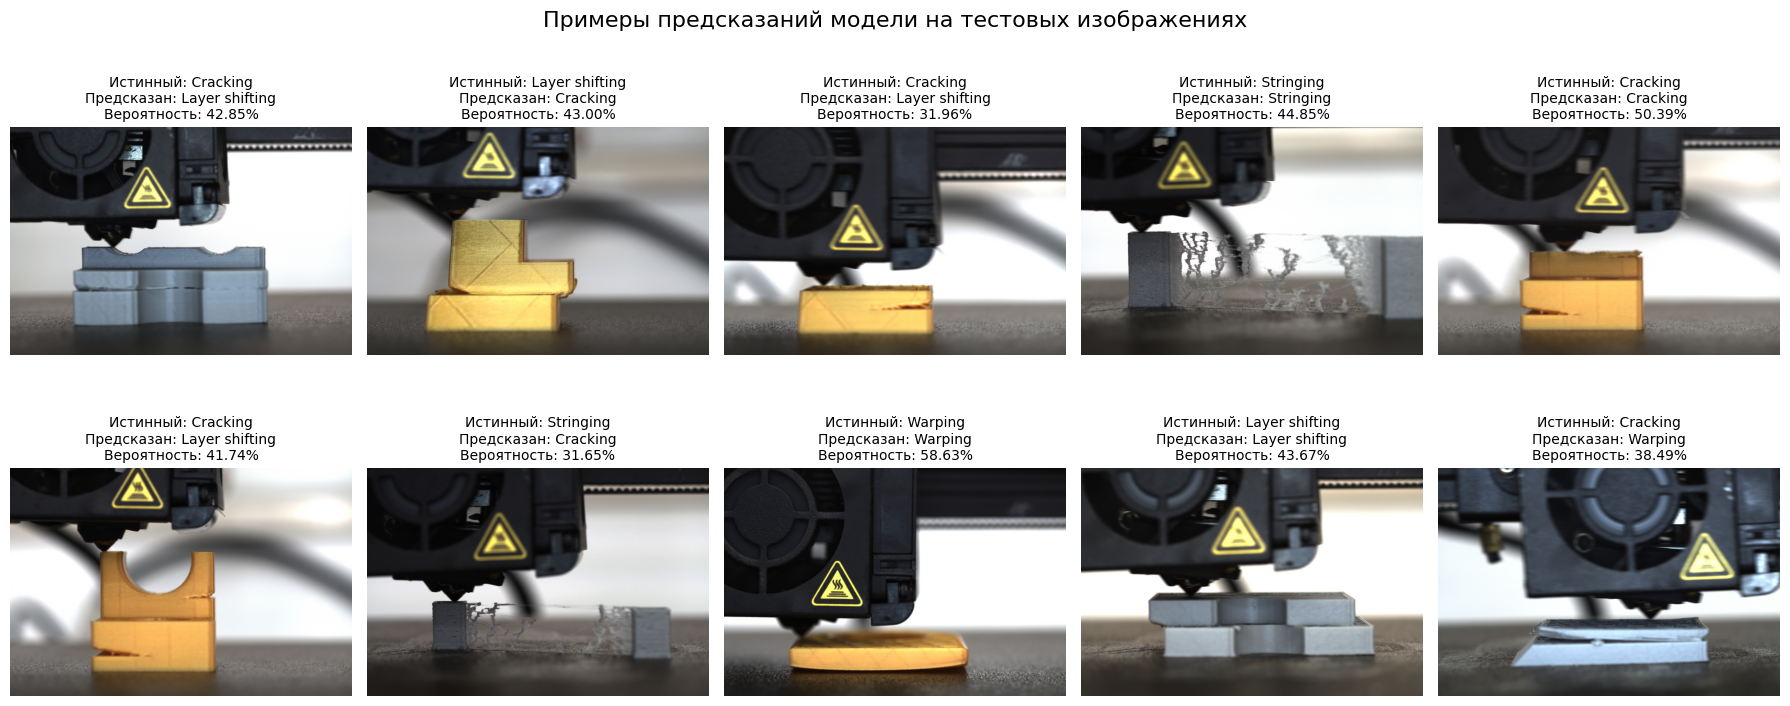


Подробные вероятности для 10 изображений:

Изображение 1
Истинный класс: Cracking
Предсказанный класс: Layer shifting
Вероятность предсказанного класса: 42.85%
Cracking: 0.3332
Layer shifting: 0.4285
Off platform: 0.0199
Stringing: 0.0737
Warping: 0.1447

Изображение 2
Истинный класс: Layer shifting
Предсказанный класс: Cracking
Вероятность предсказанного класса: 43.00%
Cracking: 0.4300
Layer shifting: 0.2825
Off platform: 0.0446
Stringing: 0.1142
Warping: 0.1287

Изображение 3
Истинный класс: Cracking
Предсказанный класс: Layer shifting
Вероятность предсказанного класса: 31.96%
Cracking: 0.2625
Layer shifting: 0.3196
Off platform: 0.0390
Stringing: 0.0745
Warping: 0.3044

Изображение 4
Истинный класс: Stringing
Предсказанный класс: Stringing
Вероятность предсказанного класса: 44.85%
Cracking: 0.1975
Layer shifting: 0.2144
Off platform: 0.0353
Stringing: 0.4485
Warping: 0.1043

Изображение 5
Истинный класс: Cracking
Предсказанный класс: Cracking
Вероятность предсказанного класса: 50.3

In [4]:
import os
import random
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.0001

DATA_DIR = os.path.join("..", "data")

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

class_names = [
    "Cracking",
    "Layer_shifting",
    "Off_platform",
    "Stringing",
    "Warping"
]

pretty_names = {
    "Cracking": "Cracking",
    "Layer_shifting": "Layer shifting",
    "Off_platform": "Off platform",
    "Stringing": "Stringing",
    "Warping": "Warping"
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



data = []

for class_name in class_names:
    class_path = os.path.join(DATA_DIR, class_name)

    for file_name in os.listdir(class_path):
        if file_name.lower().endswith(IMAGE_EXTENSIONS):
            image_path = os.path.join(class_path, file_name)
            label_index = class_names.index(class_name)

            data.append({
                "image_path": image_path,
                "label_index": label_index,
                "label_name": class_name
            })

print("Количество изображений всего:", len(data))

for class_name in class_names:
    count = sum(1 for item in data if item["label_name"] == class_name)
    print(f"{pretty_names[class_name]}: {count}")


labels = [item["label_index"] for item in data]

train_data, temp_data = train_test_split(
    data,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

temp_labels = [item["label_index"] for item in temp_data]

val_data, test_data = train_test_split(
    temp_data,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

print("\nРазмеры выборок:")
print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))


class FDMDefectDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        image_path = self.data[index]["image_path"]
        label = self.data[index]["label_index"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


train_dataset = FDMDefectDataset(train_data, transform=train_transform)
val_dataset = FDMDefectDataset(val_data, transform=val_test_transform)
test_dataset = FDMDefectDataset(test_data, transform=val_test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=LEARNING_RATE
)


def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, predictions = torch.max(outputs, 1)

        total_loss += loss.item() * images.size(0)
        correct += torch.sum(predictions == labels).item()
        total += labels.size(0)

    epoch_loss = total_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


def evaluate_model(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            _, predictions = torch.max(outputs, 1)

            total_loss += loss.item() * images.size(0)
            correct += torch.sum(predictions == labels).item()
            total += labels.size(0)

    epoch_loss = total_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0

for epoch in range(EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Эпоха {epoch + 1}/{EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train accuracy: {train_accuracy:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val accuracy: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), "best_fdm_defect_model.pth")


model.load_state_dict(
    torch.load("best_fdm_defect_model.pth", map_location=device)
)

print("\nЛучшая validation accuracy:", round(best_val_accuracy, 4))


plt.figure(figsize=(8, 5))
plt.plot(history["train_accuracy"], label="Train accuracy")
plt.plot(history["val_accuracy"], label="Validation accuracy")
plt.title("График точности модели")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("accuracy_plot.png", dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.title("График функции потерь")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_plot.png", dpi=300, bbox_inches="tight")
plt.show()


test_loss, test_accuracy = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

print("\nИтоговая оценка на тестовой выборке:")
print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy, 4))


def get_predictions(model, dataloader, device):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predictions = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    return np.array(y_true), np.array(y_pred)


y_true, y_pred = get_predictions(model, test_loader, device)

target_names = [pretty_names[class_name] for class_name in class_names]

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=target_names
    )
)


cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
plt.imshow(cm)
plt.title("Матрица ошибок")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")

plt.xticks(
    ticks=np.arange(len(class_names)),
    labels=target_names,
    rotation=30
)

plt.yticks(
    ticks=np.arange(len(class_names)),
    labels=target_names
)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


def predict_image(image_path):
    model.eval()

    original_image = Image.open(image_path).convert("RGB")
    input_tensor = val_test_transform(original_image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]

    predicted_index = torch.argmax(probabilities).item()
    predicted_class = class_names[predicted_index]
    confidence = probabilities[predicted_index].item()

    return original_image, predicted_class, confidence, probabilities.cpu().numpy()


sample_images = random.sample(test_data, 10)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, item in enumerate(sample_images):
    image_path = item["image_path"]
    true_class = item["label_name"]

    image, predicted_class, confidence, probabilities = predict_image(image_path)

    axes[i].imshow(image)
    axes[i].axis("off")

    title = (
        f"Истинный: {pretty_names[true_class]}\n"
        f"Предсказан: {pretty_names[predicted_class]}\n"
        f"Вероятность: {confidence:.2%}"
    )

    axes[i].set_title(title, fontsize=10)

plt.suptitle("Примеры предсказаний модели на тестовых изображениях", fontsize=16)
plt.tight_layout()
plt.savefig("ten_predictions.png", dpi=300, bbox_inches="tight")
plt.show()


print("\nПодробные вероятности для 10 изображений:")

for i, item in enumerate(sample_images, start=1):
    image_path = item["image_path"]
    true_class = item["label_name"]

    image, predicted_class, confidence, probabilities = predict_image(image_path)

    print(f"\nИзображение {i}")
    print("Истинный класс:", pretty_names[true_class])
    print("Предсказанный класс:", pretty_names[predicted_class])
    print("Вероятность предсказанного класса:", f"{confidence:.2%}")

    for class_name, probability in zip(class_names, probabilities):
        print(f"{pretty_names[class_name]}: {probability:.4f}")
